In [11]:
!pip install opencv-python-headless
!pip install scikit-learn
!pip install tqdm
!pip install matplotlib
!pip install seaborn

In [12]:
import cv2
import numpy as np
from PIL import Image
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
import pandas as pd
import os
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# Téléchargement depuis S3
!mc cp "s3/hlegarzic/stat_app/best_resnet18_model.pth" "/home/onyxia/best_resnet18_model.pth"
!mc cp "s3/hlegarzic/stat_app/breast-level_annotations.csv" "/home/onyxia/breast-level_annotations.csv"
!mc mirror "s3/hlegarzic/stat_app/images_png" "/home/onyxia/images_png"

# Chargement et filtrage des annotations
df = pd.read_csv("/home/onyxia/breast-level_annotations.csv")
df = df[df["view_position"] == "MLO"]
df = df[df["breast_birads"].isin(["BI-RADS 1", "BI-RADS 4", "BI-RADS 5"])]
df["label"] = (df["breast_birads"] == "BI-RADS 1").astype(int)

# Chargement du modèle
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.resnet18()
model.fc = torch.nn.Linear(model.fc.in_features, 2)
model.load_state_dict(torch.load("/home/onyxia/best_resnet18_model.pth", map_location=device))
model.eval().to(device)

# Transforms (sans normalisation d'image, CLAHE s'en charge)
transform = transforms.Compose([
    transforms.Resize((700, 700)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Fonction CLAHE
def apply_clahe(pil_img):
    img_gray = np.array(pil_img.convert("L"))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(img_gray)
    img_rgb = cv2.cvtColor(img_clahe, cv2.COLOR_GRAY2RGB)
    return Image.fromarray(img_rgb)

]11;?\mc: Configuration written to `/home/onyxia/.mc/config.json`. Please update your access credentials.
mc: Successfully created `/home/onyxia/.mc/share`.
mc: Initialized share uploads `/home/onyxia/.mc/share/uploads.json` file.
mc: Initialized share downloads `/home/onyxia/.mc/share/downloads.json` file.
...57212e.png: 7.71 GiB / 7.71 GiB ┃▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓┃ 202.52 MiB/s 38s]11;?\]11;?\

/opt/python/lib/python3.13/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12090). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [14]:
# Inférence
images_dir = "/home/onyxia/images_png"

all_predictions = []
all_labels = []
all_probabilities = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    img_path = os.path.join(images_dir, row["study_id"], row["image_id"] + ".png")

    if not os.path.exists(img_path):
        continue

    img = Image.open(img_path).convert("RGB")
    img = apply_clahe(img)
    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probabilities = F.softmax(outputs, dim=1)
        _, pred = torch.max(outputs, 1)
        all_predictions.append(pred.item())
        all_labels.append(row["label"])
        all_probabilities.append(probabilities[0][0].item())

predictions_np = np.array(all_predictions)
labels_np = np.array(all_labels)
probabilities_np = np.array(all_probabilities)

accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')

100%|██████████| 7197/7197 [31:33<00:00,  3.80it/s]

Test_Accuracy : 90.5655%


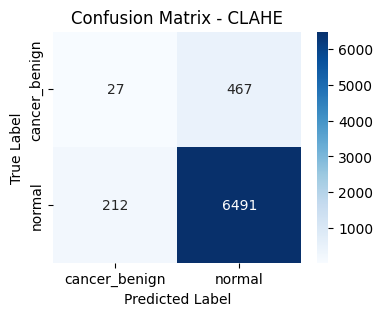

Rapport de classification : 
               precision    recall  f1-score   support

cancer_benign       0.11      0.05      0.07       494
       normal       0.93      0.97      0.95      6703

     accuracy                           0.91      7197
    macro avg       0.52      0.51      0.51      7197
 weighted avg       0.88      0.91      0.89      7197



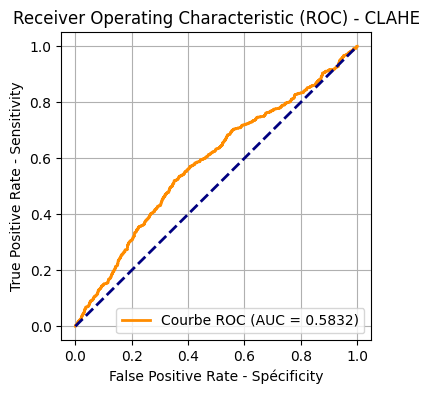

In [15]:
# Matrice de confusion
class_names = ['cancer_benign', 'normal']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CLAHE')
plt.show()

# Rapport de classification
report = classification_report(labels_np, predictions_np, target_names=class_names)
print("Rapport de classification : ")
print(report)

# Courbe ROC et AUC
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate - Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('Receiver Operating Characteristic (ROC) - CLAHE')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()